In [13]:
import tensorflow as tf
from tensorflow import keras
import os
import pandas as pd
from tensorflow.keras.models import Sequential
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers

In [3]:
PATH = 'datasets/ISIC_2020_corrected'
os.listdir(PATH)

['multiclass',
 'subset.csv',
 'test_split.csv',
 'train',
 'train.csv',
 'train_resized',
 'train_sd_split.csv',
 'train_split.csv',
 'val_split.csv']

In [28]:
train = pd.read_csv(f'{PATH}/subset.csv')
val = pd.read_csv(f'{PATH}/val_split.csv')
test = pd.read_csv(f'{PATH}/test_split.csv')
train.shape, val.shape

((2319, 9), (4969, 9))

In [29]:
BATCH_SIZE = 64
AUTO = tf.data.experimental.AUTOTUNE

def decode(name, label):
    img = tf.io.read_file(name)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.cast(img, tf.float32)
    return img, label
    
def load_ds(df):
    options = tf.data.Options()
    options.experimental_deterministic = False
    imgs, labels = df["image_name"].values, df["target"].values
    imgs = [f'{PATH}/train_resized/{name}.jpg' for name in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    ds = ds.with_options(options)
    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.cache()
    ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTO)
    return ds

In [30]:
train_ds = load_ds(train)
val_ds = load_ds(val)
test_ds = load_ds(test)

In [48]:
IMAGE_SIZE = (256, 256, 3)


model = Sequential([
  layers.Rescaling(1./255, input_shape=IMAGE_SIZE),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(1, activation='sigmoid')
])
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(name="auc", curve='PR'), keras.metrics.FalseNegatives(), keras.metrics.TruePositives()]
)
filepath = 'models/checkpoints/baseline2'
cb = tf.keras.callbacks.ModelCheckpoint(
    filepath = filepath,
    monitor="val_auc",
    verbose=0,
    save_best_only=True,
    save_weights_only=True,
    mode="max"
)
model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_14 (Rescaling)    (None, 256, 256, 3)       0         
                                                                 
 conv2d_42 (Conv2D)          (None, 256, 256, 16)      448       
                                                                 
 max_pooling2d_42 (MaxPoolin  (None, 128, 128, 16)     0         
 g2D)                                                            
                                                                 
 conv2d_43 (Conv2D)          (None, 128, 128, 32)      4640      
                                                                 
 max_pooling2d_43 (MaxPoolin  (None, 64, 64, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_44 (Conv2D)          (None, 64, 64, 64)      

In [49]:
history = model.fit(train_ds,
                    epochs=10,
                    validation_data=val_ds,
                    #validation_steps=10,
                    callbacks=[cb]
                   )

Epoch 1/10
37/37 [==============================] - 5s 126ms/step - loss: 0.1127 - auc: 0.0248 - false_negatives_12: 41.0000 - true_positives_12: 0.0000e+00 - val_loss: 0.0852 - val_auc: 0.0373 - val_false_negatives_12: 88.0000 - val_true_positives_12: 0.0000e+00
Epoch 2/10
37/37 [==============================] - 4s 115ms/step - loss: 0.0984 - auc: 0.0295 - false_negatives_12: 41.0000 - true_positives_12: 0.0000e+00 - val_loss: 0.0935 - val_auc: 0.0346 - val_false_negatives_12: 88.0000 - val_true_positives_12: 0.0000e+00
Epoch 3/10
37/37 [==============================] - 4s 115ms/step - loss: 0.0899 - auc: 0.0239 - false_negatives_12: 41.0000 - true_positives_12: 0.0000e+00 - val_loss: 0.0926 - val_auc: 0.0369 - val_false_negatives_12: 88.0000 - val_true_positives_12: 0.0000e+00
Epoch 4/10
37/37 [==============================] - 4s 116ms/step - loss: 0.0932 - auc: 0.0265 - false_negatives_12: 41.0000 - true_positives_12: 0.0000e+00 - val_loss: 0.0853 - val_auc: 0.0355 - val_false_ne

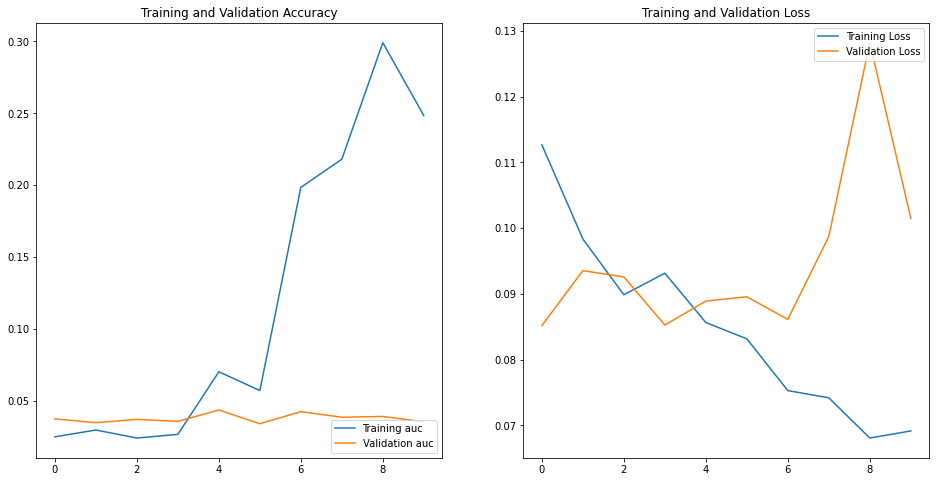

In [51]:
auc = history.history['auc']
val_auc = history.history['val_auc']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, auc, label='Training auc')
plt.plot(epochs_range, val_auc, label='Validation auc')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()